# Systematic Layer-wise CWE Evaluation & File-Type Ablation

**Goal**: Two complementary analyses:

1. **Per-layer CWE separation**: Do different CWE families produce systematically different activation deltas across layers?

2. **File-type ablation**: Ensure CWE-specific patterns cannot be explained by file type alone.


In [ ]:
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.spatial.distance import cdist
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
SEED = 42
np.random.seed(SEED)
print("Imports OK")

---
## Registry — add new runs here

Each entry describes one activation run. The loader auto-detects  tensors (fast) or falls back to JSONL.

| key | meaning |
|---|---|
|  | Path to the run folder inside  |
|  | Short human-readable name shown in plots |
|  |  = load all available layers; or a  to pick specific ones |
|  |  = SAE features,  = raw residual stream |
|  | Skip a layer file if it has fewer rows than this |

In [ ]:
ARTIFACTS = Path("../../artifacts/activations")

RUNS_REGISTRY = [
    # ── Qwen Coder – Raw activations ───────────────────────────────────────────────────────────────
    {
        "run_dir":     ARTIFACTS / "raw_activations/vulnerable_code_qwen_coder_standard_16384_raw",
        "label":       "Qwen-CL-raw",
        "layers":      None,
        "kind":        "raw",
        "min_samples": 100,
    },
    {
        "run_dir":     ARTIFACTS / "TO_UPLOAD",
        "label":       "Qwen-STD-layer0",
        "layers":      None,
        "kind":        "sae",
        "min_samples": 100,
    },
]

## Loading utilities & auto-discovery

In [ ]:
def load_jsonl_meta(jsonl_path):
    records = []
    with jsonl_path.open() as f:
        for line in f:
            line = line.strip()
            if not line: continue
            r = json.loads(line)
            records.append({"vuln_id": r["vuln_id"], "cwe": r["cwe"], "file_extension": r["file_extension"]})
    return pd.DataFrame(records)


def load_jsonl_activations(jsonl_path):
    secure_rows, vuln_rows = [], []
    with jsonl_path.open() as f:
        for line in f:
            line = line.strip()
            if not line: continue
            r = json.loads(line)
            secure_rows.append(r["secure"])
            vuln_rows.append(r["vulnerable"])
    return np.array(secure_rows, dtype=np.float32), np.array(vuln_rows, dtype=np.float32)


def discover_layers(run_dir):
    layers = set()
    for f in run_dir.glob("activations_layer_*_*.jsonl"):
        try: layers.add(int(f.name.split("_")[2]))
        except (IndexError, ValueError): pass
    return sorted(layers)


def load_layer(run_dir, layer):
    """Load (safe, vuln, meta) for one layer. Prefers .pt tensors, falls back to JSONL."""
    safe_pt = run_dir / f"safe_layer_{layer}.pt"
    vuln_pt = run_dir / f"vulnerable_layer_{layer}.pt"
    if safe_pt.exists() and vuln_pt.exists():
        safe_mat = torch.load(safe_pt, weights_only=True).numpy().astype(np.float32)
        vuln_mat = torch.load(vuln_pt, weights_only=True).numpy().astype(np.float32)
    else:
        matches = list(run_dir.glob(f"activations_layer_{layer}_*.jsonl"))
        if not matches: return None
        safe_mat, vuln_mat = load_jsonl_activations(matches[0])
    meta_matches = list(run_dir.glob(f"activations_layer_{layer}_*.jsonl"))
    if not meta_matches: return None
    return safe_mat, vuln_mat, load_jsonl_meta(meta_matches[0])


print("Loaders defined")

In [25]:
# layers_data: {label -> (delta, meta, dim_label)}
layers_data = {}

for entry in tqdm(RUNS_REGISTRY):
    run_dir = entry["run_dir"]
    run_label = entry["label"]
    kind = entry["kind"]
    min_n = entry.get("min_samples", 100)

    if not run_dir.exists():
        print(f"[SKIP] {run_label}: directory not found")
        continue

    available = discover_layers(run_dir)
    wanted = entry["layers"] if entry["layers"] is not None else available
    layers_to_load = [l for l in wanted if l in available]

    for layer in layers_to_load:
        result = load_layer(run_dir, layer)
        if result is None:
            print(f"  [SKIP] {run_label} L{layer}: no data")
            continue
        safe_mat, vuln_mat, meta = result
        if len(meta) < min_n:
            print(f"  [SKIP] {run_label} L{layer}: {len(meta)} samples < {min_n}")
            continue
        delta = vuln_mat - safe_mat
        layers_data[f"{run_label} L{layer}"] = (delta, meta, f"{kind} {delta.shape[1]}-dim")

print(f"Loaded {len(layers_data)} layer entries:")
for lbl, (d, m, dim) in layers_data.items():
    print(f"  {lbl:40s}  delta={d.shape}  n={len(m)}")

100%|██████████| 2/2 [03:30<00:00, 105.12s/it]

Loaded 16 layer entries:
  Qwen-CL-raw L0                            delta=(2493, 3584)  n=2493
  Qwen-CL-raw L3                            delta=(2493, 3584)  n=2493
  Qwen-CL-raw L7                            delta=(2493, 3584)  n=2493
  Qwen-CL-raw L11                           delta=(2493, 3584)  n=2493
  Qwen-CL-raw L15                           delta=(2493, 3584)  n=2493
  Qwen-CL-raw L19                           delta=(2493, 3584)  n=2493
  Qwen-CL-raw L23                           delta=(2493, 3584)  n=2493
  Qwen-CL-raw L27                           delta=(2493, 3584)  n=2493
  Qwen-STD-layer0 L0                        delta=(2493, 16384)  n=2493
  Qwen-STD-layer0 L3                        delta=(2493, 16384)  n=2493
  Qwen-STD-layer0 L7                        delta=(2493, 16384)  n=2493
  Qwen-STD-layer0 L11                       delta=(2493, 16384)  n=2493
  Qwen-STD-layer0 L15                       delta=(2493, 16384)  n=2493
  Qwen-STD-layer0 L19                       del

---
## CWE Family Grouping

In [26]:
CWE_FAMILIES = {
    "Memory Safety":   ["CWE-119","CWE-125","CWE-787","CWE-476","CWE-120",
                        "CWE-416","CWE-401","CWE-190","CWE-122","CWE-121","CWE-415"],
    "Injection":       ["CWE-89","CWE-79","CWE-78","CWE-94","CWE-77"],
    "Info Disclosure": ["CWE-200","CWE-209"],
    "Access Control":  ["CWE-264","CWE-287","CWE-22","CWE-284","CWE-285"],
    "Resource Mgmt":   ["CWE-400","CWE-399","CWE-369","CWE-362","CWE-20","CWE-770"],
}
CWE_TO_FAMILY = {c: f for f, cs in CWE_FAMILIES.items() for c in cs}
MAIN_FAMILIES = list(CWE_FAMILIES.keys())
ALL_FAMILIES  = MAIN_FAMILIES + ["Other"]
PALETTE = dict(zip(ALL_FAMILIES, sns.color_palette("tab10", n_colors=len(ALL_FAMILIES))))

for label, (delta, meta, dim_label) in layers_data.items():
    if "family" not in meta.columns:
        meta["family"] = meta["cwe"].map(CWE_TO_FAMILY).fillna("Other")

first_meta = next(iter(layers_data.values()))[1]
print(first_meta["family"].value_counts())

family
Memory Safety      1129
Injection           543
Resource Mgmt       417
Access Control      164
Info Disclosure     143
Other                97
Name: count, dtype: int64


---
## 1. CWE × File-Type Confound

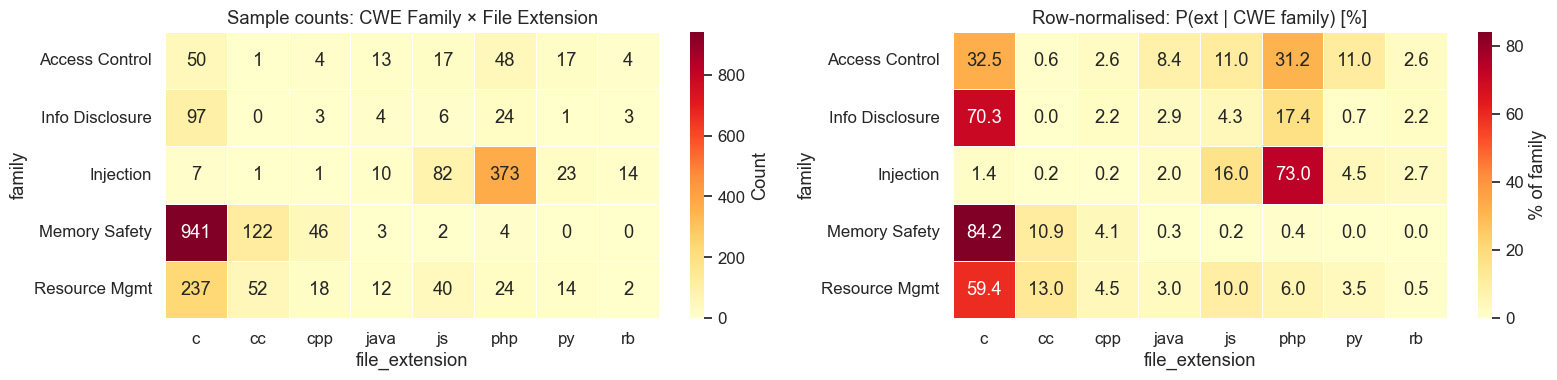

In [27]:
ref_meta = first_meta.copy()
top_exts = ref_meta["file_extension"].value_counts().head(8).index.tolist()
df_filt  = ref_meta[ref_meta["family"].isin(MAIN_FAMILIES) & ref_meta["file_extension"].isin(top_exts)]

pivot     = df_filt.pivot_table(index="family", columns="file_extension", aggfunc="size", fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(pivot,     annot=True, fmt="d",   cmap="YlOrRd", ax=axes[0], linewidths=.4, cbar_kws={"label": "Count"})
sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], linewidths=.4, cbar_kws={"label": "% of family"})
axes[0].set_title("Sample counts: CWE Family × File Extension")
axes[1].set_title("Row-normalised: P(ext | CWE family) [%]")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("cwe_filetype_confound.pdf", bbox_inches="tight")
plt.show()

---
## 2. Per-Layer Delta Analysis

### 2a. PCA projections

Edit  to control which layers appear in the grid.

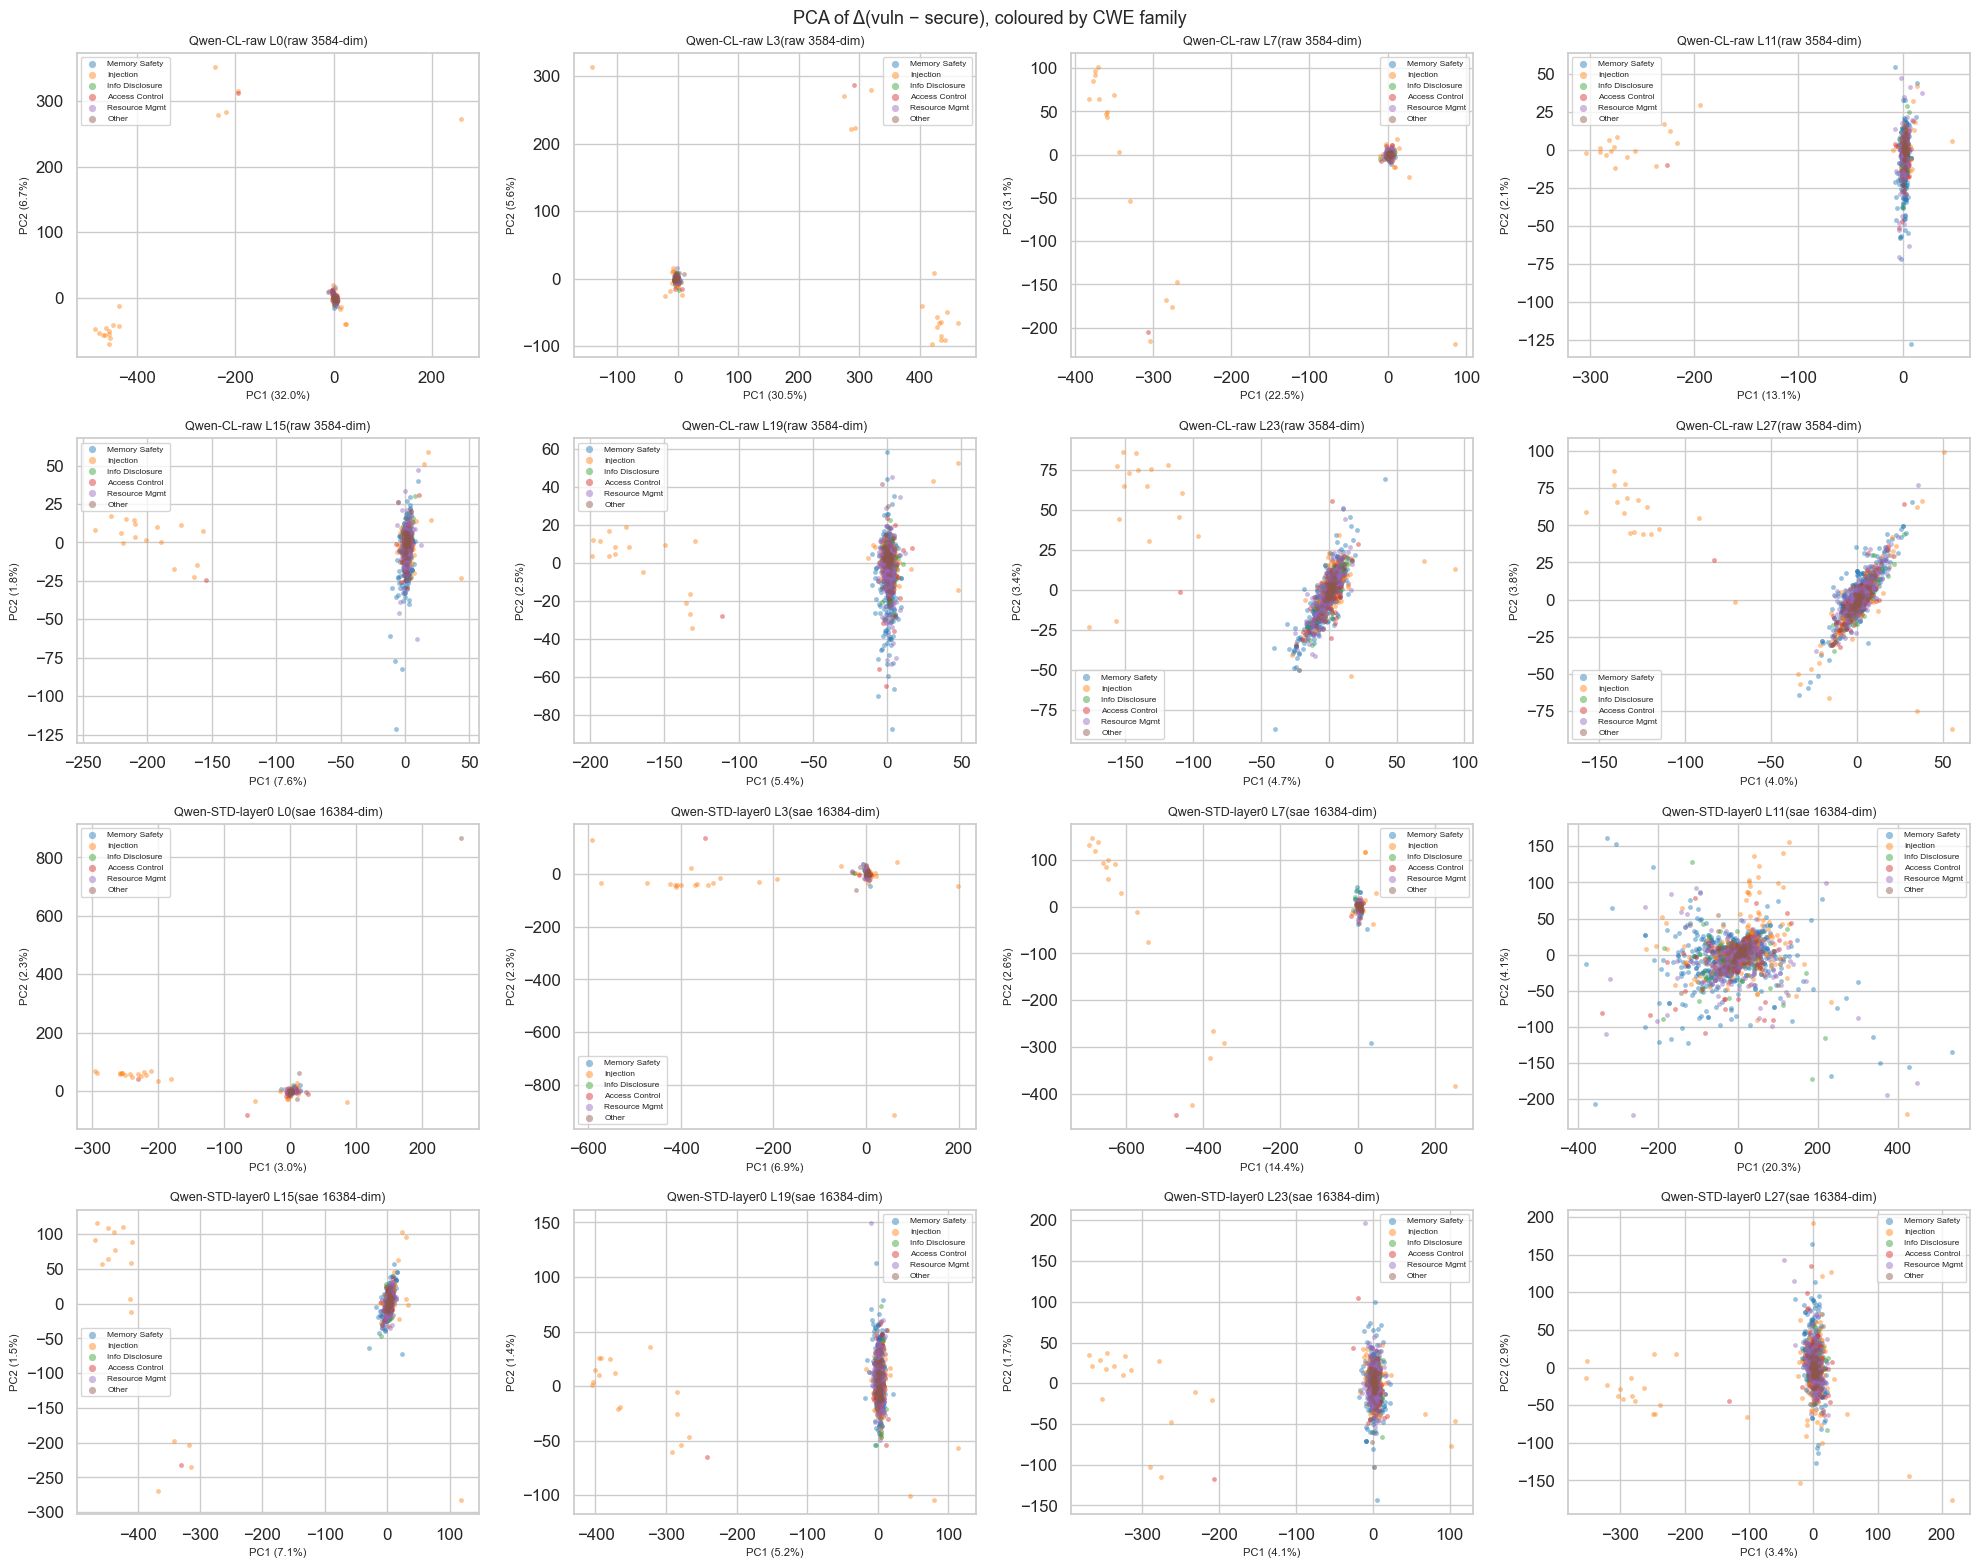

In [28]:
# Edit here to choose which layers to visualise
# plot_labels = list(layers_data.keys())                        # all
# plot_labels = [l for l in layers_data if "Gemma" in l]        # one run only
# plot_labels = [l for l in layers_data if l.endswith(" L0")]   # layer-0 across runs
plot_labels = list(layers_data.keys())

ncols = 4
nrows = math.ceil(len(plot_labels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, label in zip(axes, plot_labels):
    delta, meta, dim_label = layers_data[label]
    scaler = StandardScaler()
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(scaler.fit_transform(delta))
    var_exp = pca.explained_variance_ratio_ * 100
    for fam in ALL_FAMILIES:
        mask = meta["family"].values == fam
        if mask.sum() == 0: continue
        ax.scatter(coords[mask,0], coords[mask,1],
                   c=[PALETTE[fam]], label=fam, alpha=0.45, s=12, linewidths=0)
    ax.set_title(f"{label}({dim_label})", fontsize=9)
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=8)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=8)
    ax.legend(fontsize=6, markerscale=1.5)

for ax in axes[len(plot_labels):]: ax.set_visible(False)
fig.suptitle("PCA of Δ(vuln − secure), coloured by CWE family", fontsize=13)
plt.tight_layout()
plt.savefig("layer_pca_cwe_families.pdf", bbox_inches="tight")
plt.show()

### 2b. Linear probe AUC (one-vs-rest per CWE family)

In [29]:
def probe_cwe_families(delta, meta, families, n_components=50, cv=5):
    scaler = StandardScaler()
    pca = PCA(n_components=min(n_components, delta.shape[1], delta.shape[0]-1), random_state=SEED)
    X = pca.fit_transform(scaler.fit_transform(delta))
    rows = []
    for fam in families:
        y = (meta["family"].values == fam).astype(int)
        if y.sum() < 10 or (1-y).sum() < 10: continue
        clf = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced", random_state=SEED)
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
        auc = cross_val_score(clf, X, y, cv=skf, scoring="roc_auc").mean()
        rows.append({"family": fam, "n_pos": int(y.sum()), "roc_auc": auc})
    return pd.DataFrame(rows).set_index("family")

In [30]:
probe_results = {}
for label, (delta, meta, _) in layers_data.items():
    print(f"  Probing {label} ...", end=" ", flush=True)
    probe_results[label] = probe_cwe_families(delta, meta, MAIN_FAMILIES)
    print("done")

  Probing Qwen-CL-raw L0 ... done
  Probing Qwen-CL-raw L3 ... done
  Probing Qwen-CL-raw L7 ... done
  Probing Qwen-CL-raw L11 ... done
  Probing Qwen-CL-raw L15 ... done
  Probing Qwen-CL-raw L19 ... done
  Probing Qwen-CL-raw L23 ... done
  Probing Qwen-CL-raw L27 ... done
  Probing Qwen-STD-layer0 L0 ... done
  Probing Qwen-STD-layer0 L3 ... done
  Probing Qwen-STD-layer0 L7 ... done
  Probing Qwen-STD-layer0 L11 ... done
  Probing Qwen-STD-layer0 L15 ... done
  Probing Qwen-STD-layer0 L19 ... done
  Probing Qwen-STD-layer0 L23 ... done
  Probing Qwen-STD-layer0 L27 ... done


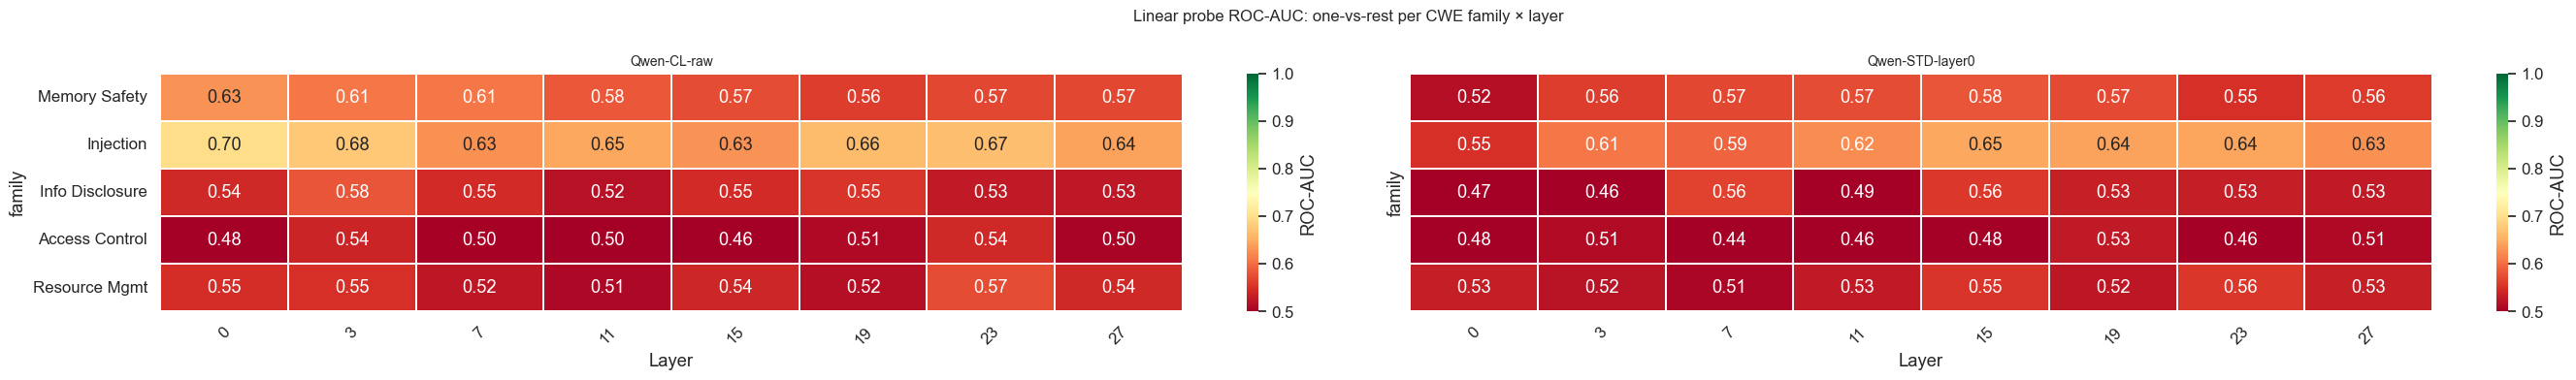

In [31]:
auc_table = pd.DataFrame({lbl: res["roc_auc"] for lbl, res in probe_results.items()})

# Group columns by run so each run gets its own heatmap (handles many layers)
run_groups = {}
for lbl in auc_table.columns:
    run_name = lbl.rsplit(" L", 1)[0]
    run_groups.setdefault(run_name, []).append(lbl)

n_runs = len(run_groups)
max_layers = max(len(v) for v in run_groups.values())
fig, axes = plt.subplots(1, n_runs, figsize=(max(5, 1.5*max_layers+2)*n_runs, 4),
                          sharey=True)
if n_runs == 1: axes = [axes]

for ax, (run_name, lbls) in zip(axes, run_groups.items()):
    sub = auc_table[lbls].rename(columns=lambda l: l.rsplit(" L",1)[-1])
    sns.heatmap(sub, annot=True, fmt=".2f", cmap="RdYlGn",
                ax=ax, vmin=0.5, vmax=1.0, linewidths=0.3, cbar_kws={"label": "ROC-AUC"})
    ax.set_title(run_name, fontsize=10)
    ax.set_xlabel("Layer")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Linear probe ROC-AUC: one-vs-rest per CWE family × layer", fontsize=12)
plt.tight_layout()
plt.savefig("probe_auc_per_layer.pdf", bbox_inches="tight")
plt.show()

### 2c. CWE centroid distances

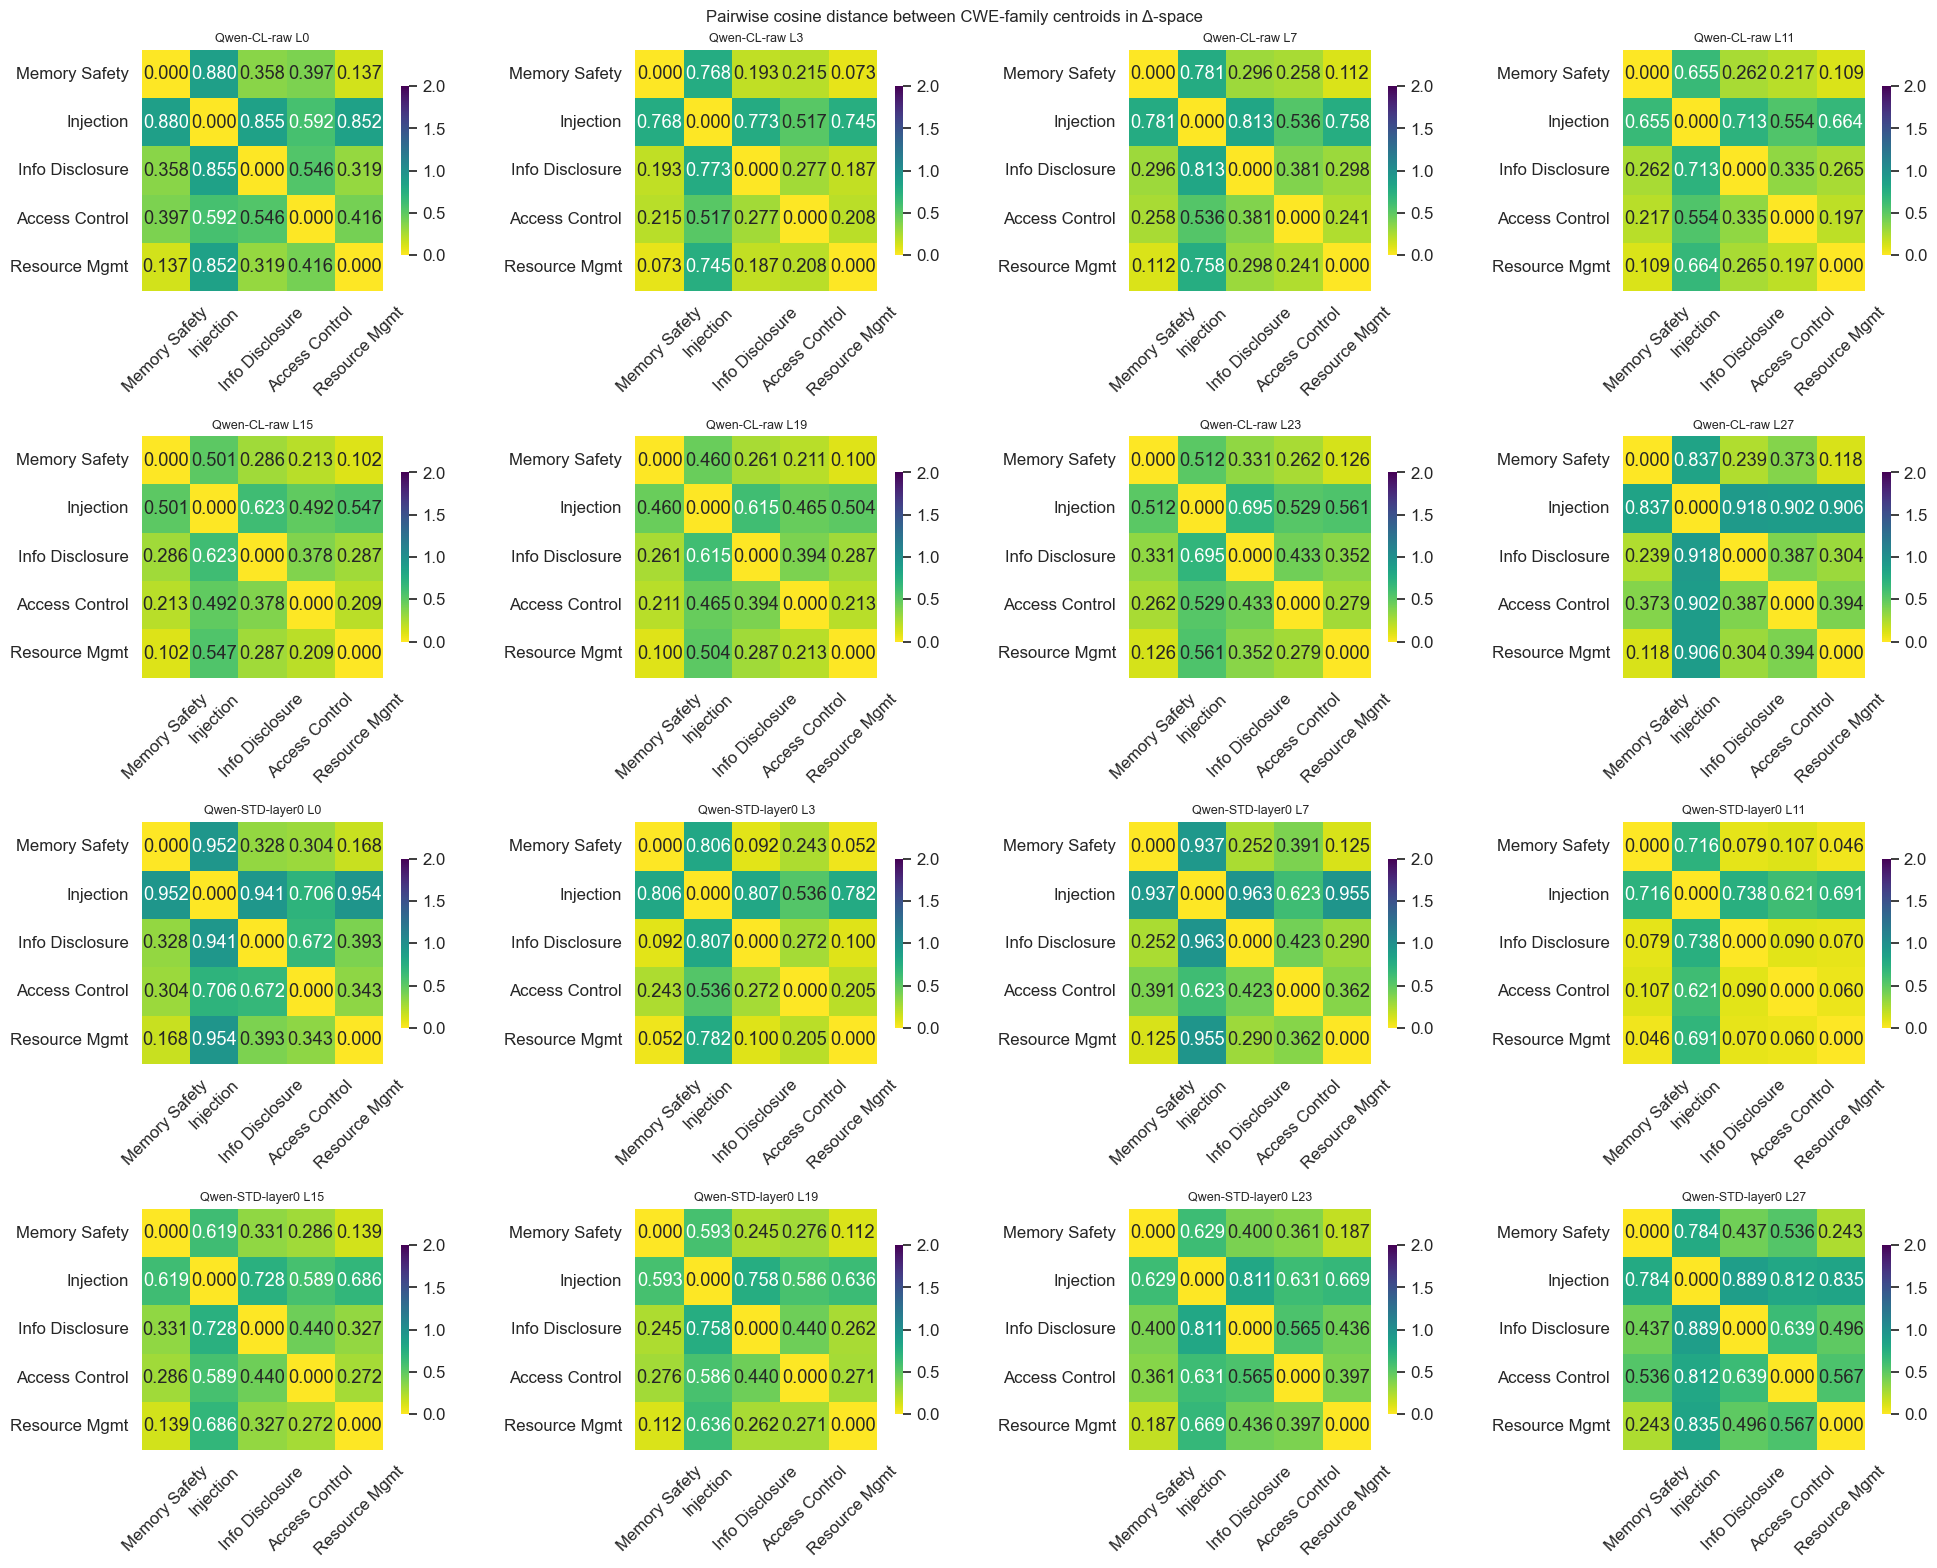

In [32]:
def centroid_distances(delta, meta, families, metric="cosine"):
    centroids, valid = [], []
    for fam in families:
        mask = meta["family"].values == fam
        if mask.sum() < 5: continue
        centroids.append(delta[mask].mean(axis=0)); valid.append(fam)
    D = cdist(np.stack(centroids), np.stack(centroids), metric=metric)
    return pd.DataFrame(D, index=valid, columns=valid)


ncols = 4
nrows = math.ceil(len(plot_labels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten()

for ax, label in zip(axes, plot_labels):
    delta, meta, _ = layers_data[label]
    dist_df = centroid_distances(delta, meta, MAIN_FAMILIES)
    sns.heatmap(dist_df, annot=True, fmt=".3f", cmap="viridis_r",
                ax=ax, square=True, vmin=0, vmax=2, cbar_kws={"shrink":0.7})
    ax.set_title(label, fontsize=9)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(plot_labels):]: ax.set_visible(False)
fig.suptitle("Pairwise cosine distance between CWE-family centroids in Δ-space", fontsize=12)
plt.tight_layout()
plt.savefig("layer_centroid_distances.pdf", bbox_inches="tight")
plt.show()

---
## 3. File-Type Ablation

**Null hypothesis**: CWE-family signal in δ is entirely explained by file type (language artefact).

**Tests**: (1) residualise OHE(file_ext) out of δ, re-run probes; (2) within-file-type probing; (3) ANOVA.

In [33]:
def residualise_filetype(delta, meta):
    ext_ohe = pd.get_dummies(meta["file_extension"], drop_first=False).astype(float).values
    ridge = Ridge(alpha=1.0, fit_intercept=True)
    ridge.fit(ext_ohe, delta)
    return (delta - ridge.predict(ext_ohe)).astype(np.float32)


layers_data_resid = {}
for label, (delta, meta, dim_label) in layers_data.items():
    resid = residualise_filetype(delta, meta)
    layers_data_resid[label] = (resid, meta, dim_label)
    r2 = 1 - np.var(resid) / np.var(delta)
    print(f"{label:40s}  R²(file_type) = {r2:.4f}")

Qwen-CL-raw L0                            R²(file_type) = 0.0197
Qwen-CL-raw L3                            R²(file_type) = 0.0279
Qwen-CL-raw L7                            R²(file_type) = 0.0215
Qwen-CL-raw L11                           R²(file_type) = 0.0209
Qwen-CL-raw L15                           R²(file_type) = 0.0217
Qwen-CL-raw L19                           R²(file_type) = 0.0222
Qwen-CL-raw L23                           R²(file_type) = 0.0174
Qwen-CL-raw L27                           R²(file_type) = 0.0144
Qwen-STD-layer0 L0                        R²(file_type) = 0.0175
Qwen-STD-layer0 L3                        R²(file_type) = 0.0302
Qwen-STD-layer0 L7                        R²(file_type) = 0.0181
Qwen-STD-layer0 L11                       R²(file_type) = 0.0321
Qwen-STD-layer0 L15                       R²(file_type) = 0.0178
Qwen-STD-layer0 L19                       R²(file_type) = 0.0197
Qwen-STD-layer0 L23                       R²(file_type) = 0.0136
Qwen-STD-layer0 L27      

In [34]:
probe_results_resid = {}
for label, (resid, meta, _) in layers_data_resid.items():
    print(f"  Probing (residualised) {label} ...", end=" ", flush=True)
    probe_results_resid[label] = probe_cwe_families(resid, meta, MAIN_FAMILIES)
    print("done")

  Probing (residualised) Qwen-CL-raw L0 ... done
  Probing (residualised) Qwen-CL-raw L3 ... done
  Probing (residualised) Qwen-CL-raw L7 ... done
  Probing (residualised) Qwen-CL-raw L11 ... done
  Probing (residualised) Qwen-CL-raw L15 ... done
  Probing (residualised) Qwen-CL-raw L19 ... done
  Probing (residualised) Qwen-CL-raw L23 ... done
  Probing (residualised) Qwen-CL-raw L27 ... done
  Probing (residualised) Qwen-STD-layer0 L0 ... done
  Probing (residualised) Qwen-STD-layer0 L3 ... done
  Probing (residualised) Qwen-STD-layer0 L7 ... done
  Probing (residualised) Qwen-STD-layer0 L11 ... done
  Probing (residualised) Qwen-STD-layer0 L15 ... done
  Probing (residualised) Qwen-STD-layer0 L19 ... done
  Probing (residualised) Qwen-STD-layer0 L23 ... done
  Probing (residualised) Qwen-STD-layer0 L27 ... done


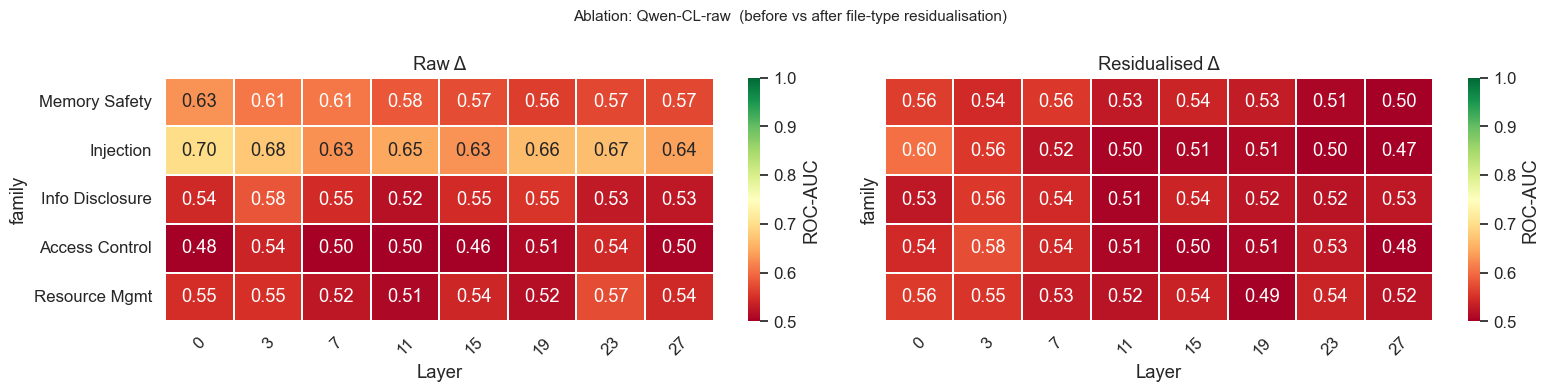

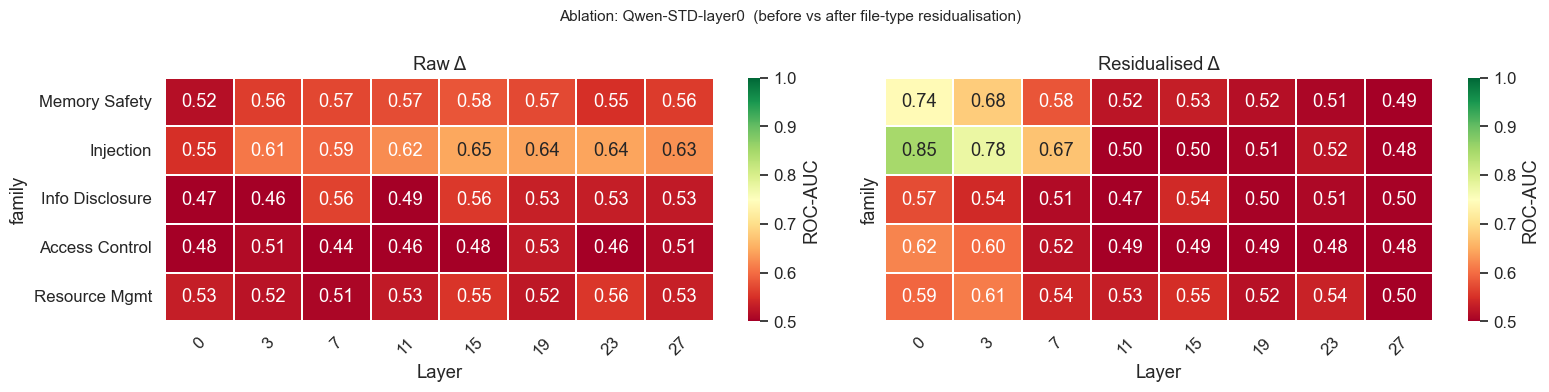

ΔAUC (after − before):
                 Qwen-CL-raw L0  Qwen-CL-raw L3  Qwen-CL-raw L7  \
family                                                            
Memory Safety            -0.068          -0.066          -0.050   
Injection                -0.096          -0.120          -0.105   
Info Disclosure          -0.015          -0.024          -0.004   
Access Control            0.068           0.038           0.041   
Resource Mgmt             0.013           0.004           0.006   

                 Qwen-CL-raw L11  Qwen-CL-raw L15  Qwen-CL-raw L19  \
family                                                               
Memory Safety             -0.055           -0.036           -0.031   
Injection                 -0.142           -0.124           -0.153   
Info Disclosure           -0.013           -0.009           -0.032   
Access Control             0.005            0.035           -0.005   
Resource Mgmt              0.013           -0.004           -0.021   

                

In [35]:
auc_before = pd.DataFrame({lbl: res["roc_auc"] for lbl, res in probe_results.items()})
auc_after  = pd.DataFrame({lbl: res["roc_auc"] for lbl, res in probe_results_resid.items()})

for run_name, lbls in run_groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(max(8, 1.5*len(lbls)+4), 4), sharey=True)
    for ax, (title, auc_df) in zip(axes, [
        ("Raw Δ", auc_before[lbls].rename(columns=lambda l: l.rsplit(" L",1)[-1])),
        ("Residualised Δ", auc_after[lbls].rename(columns=lambda l: l.rsplit(" L",1)[-1])),
    ]):
        sns.heatmap(auc_df, annot=True, fmt=".2f", cmap="RdYlGn",
                    ax=ax, vmin=0.5, vmax=1.0, linewidths=0.3, cbar_kws={"label":"ROC-AUC"})
        ax.set_title(title); ax.set_xlabel("Layer"); ax.tick_params(axis="x", rotation=45)
    fig.suptitle(f"Ablation: {run_name}  (before vs after file-type residualisation)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"ablation_{run_name.replace(" ","_")}.pdf", bbox_inches="tight")
    plt.show()

print("ΔAUC (after − before):")
print((auc_after - auc_before).round(3))

### 3b. Within-file-type probing

Probes restricted to a single file extension. Uses the entry with the most samples.

Using: Qwen-CL-raw L0


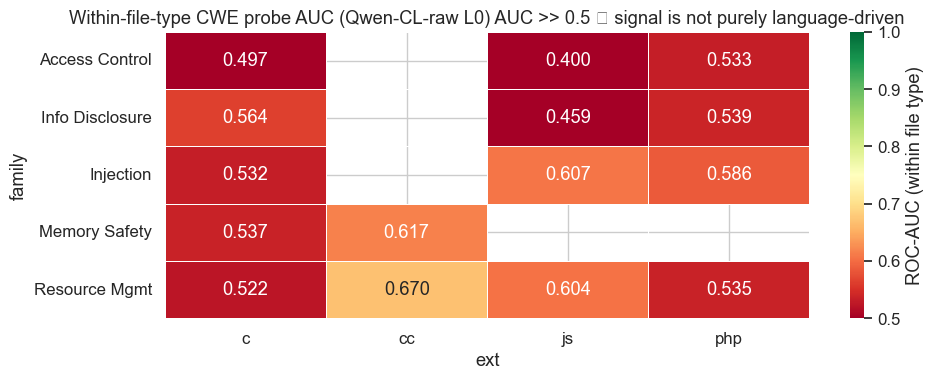

In [36]:
best_label = max(layers_data, key=lambda l: len(layers_data[l][1]))
print(f"Using: {best_label}")
delta_best, meta_best, _ = layers_data[best_label]

rows_wf = []
for ext, grp in meta_best.groupby("file_extension"):
    idx = grp.index.values
    if len(idx) < 80: continue
    d_sub = delta_best[idx]; m_sub = meta_best.loc[idx]
    scaler = StandardScaler()
    pca = PCA(n_components=min(30, d_sub.shape[1], len(idx)-1), random_state=SEED)
    X = pca.fit_transform(scaler.fit_transform(d_sub))
    for fam in MAIN_FAMILIES:
        y = (m_sub["family"].values == fam).astype(int)
        if y.sum() < 5 or (1-y).sum() < 5: continue
        clf = LogisticRegression(C=0.1, max_iter=500, class_weight="balanced", random_state=SEED)
        skf = StratifiedKFold(n_splits=min(5, y.sum()), shuffle=True, random_state=SEED)
        try:
            auc = cross_val_score(clf, X, y, cv=skf, scoring="roc_auc").mean()
            rows_wf.append({"ext": ext, "family": fam, "roc_auc": auc, "n": len(idx)})
        except: pass

within_df = pd.DataFrame(rows_wf)
if not within_df.empty:
    pivot_wf = within_df.pivot_table(index="family", columns="ext", values="roc_auc")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot_wf, annot=True, fmt=".3f", cmap="RdYlGn",
                ax=ax, vmin=0.5, vmax=1.0, linewidths=0.4, cbar_kws={"label":"ROC-AUC (within file type)"})
    ax.set_title(f"Within-file-type CWE probe AUC ({best_label}) AUC >> 0.5 ⟹ signal is not purely language-driven")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig("within_filetype_probe.pdf", bbox_inches="tight")
    plt.show()

### 3c. ANOVA: CWE effect per PCA component

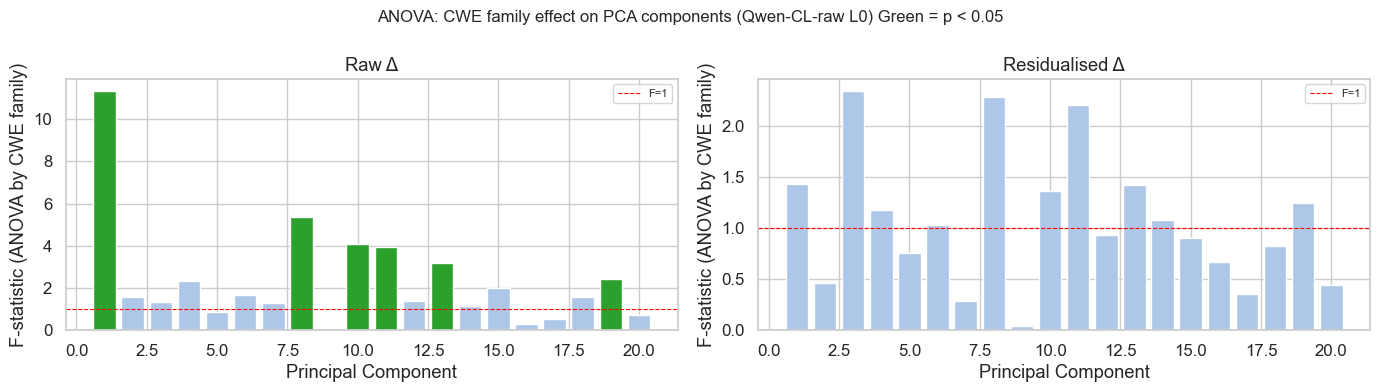

In [37]:
def anova_cwe_pca(delta, meta, families, n_components=20):
    X = PCA(n_components=n_components, random_state=SEED).fit_transform(
        StandardScaler().fit_transform(delta))
    valid = meta["family"].isin(families).values
    X_f, labs = X[valid], meta["family"].values[valid]
    rows = []
    for pc in range(n_components):
        groups = [X_f[labs==f, pc] for f in families if (labs==f).sum() > 0]
        f_stat, p_val = f_oneway(*groups)
        rows.append({"PC": pc+1, "F": f_stat, "p": p_val})
    return pd.DataFrame(rows)


delta_b, meta_b, _ = layers_data[best_label]
resid_b, _, _      = layers_data_resid[best_label]
anova_raw   = anova_cwe_pca(delta_b, meta_b, MAIN_FAMILIES)
anova_resid = anova_cwe_pca(resid_b, meta_b, MAIN_FAMILIES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (title, df) in zip(axes, [
    ("Raw Δ", anova_raw), ("Residualised Δ", anova_resid)
]):
    ax.bar(df["PC"], df["F"], color=np.where(df["p"]<0.05, "#2ca02c", "#aec7e8"))
    ax.axhline(1, color="red", linestyle="--", lw=0.8, label="F=1")
    ax.set_title(title); ax.set_xlabel("Principal Component")
    ax.set_ylabel("F-statistic (ANOVA by CWE family)"); ax.legend(fontsize=8)
fig.suptitle(f"ANOVA: CWE family effect on PCA components ({best_label}) Green = p < 0.05", fontsize=12)
plt.tight_layout()
plt.savefig("anova_cwe_pca.pdf", bbox_inches="tight")
plt.show()

---
## 4. Summary

In [38]:
rows = []
for label in layers_data:
    for fam in MAIN_FAMILIES:
        before = probe_results[label]["roc_auc"].get(fam, float("nan"))
        after  = probe_results_resid[label]["roc_auc"].get(fam, float("nan"))
        rows.append({
            "Layer": label, "CWE Family": fam,
            "AUC raw": round(before, 3), "AUC resid": round(after, 3),
            "ΔAUC": round(after-before, 3) if not (np.isnan(before) or np.isnan(after)) else float("nan"),
        })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

              Layer      CWE Family  AUC raw  AUC resid   ΔAUC
     Qwen-CL-raw L0   Memory Safety    0.630      0.562 -0.068
     Qwen-CL-raw L0       Injection    0.699      0.603 -0.096
     Qwen-CL-raw L0 Info Disclosure    0.542      0.527 -0.015
     Qwen-CL-raw L0  Access Control    0.477      0.545  0.068
     Qwen-CL-raw L0   Resource Mgmt    0.547      0.560  0.013
     Qwen-CL-raw L3   Memory Safety    0.609      0.543 -0.066
     Qwen-CL-raw L3       Injection    0.678      0.557 -0.120
     Qwen-CL-raw L3 Info Disclosure    0.582      0.558 -0.024
     Qwen-CL-raw L3  Access Control    0.538      0.576  0.038
     Qwen-CL-raw L3   Resource Mgmt    0.550      0.554  0.004
     Qwen-CL-raw L7   Memory Safety    0.608      0.557 -0.050
     Qwen-CL-raw L7       Injection    0.629      0.523 -0.105
     Qwen-CL-raw L7 Info Disclosure    0.547      0.543 -0.004
     Qwen-CL-raw L7  Access Control    0.502      0.543  0.041
     Qwen-CL-raw L7   Resource Mgmt    0.524      0.530

## Interpretation Guide

| Observation | Interpretation |
|---|---|
| **High AUC raw + High AUC resid** | Strong CWE signal, **not** a file-type artefact |
| **High AUC raw + Low AUC resid** | Signal driven by language, not vulnerability type |
| **Low AUC raw** | No CWE signal at this layer |
| **AUC grows with layer depth** | Deeper layers encode more vulnerability-type info |
| **ANOVA F stays high after residualisation** | CWE explains variance beyond file type |
| **Within-filetype AUC >> 0.5** | CWE signal exists within a single language |

---
## 5. Within-Language Evaluation

**Motivation (reviewer test):** If the CWE-family separation is purely language-mediated, then probes
restricted to a *single* file extension should collapse toward chance. If genuine mechanistic signal exists,
AUC should remain elevated even within a homogeneous language stratum.

We run one-vs-rest probes **within each major language** (`.c`, `.php`, `.js`) across all layers,
for both raw and SAE representations.

In [ ]:
def probe_within_language(delta, meta, ext, families, n_components=30, cv=5):
    """One-vs-rest CWE probes restricted to samples with file_extension == ext."""
    mask = (meta["file_extension"] == ext).values
    if mask.sum() < 30:
        return None
    d_sub = delta[mask]
    m_sub = meta[mask].reset_index(drop=True)
    scaler = StandardScaler()
    pca = PCA(n_components=min(n_components, d_sub.shape[1], d_sub.shape[0] - 1), random_state=SEED)
    X = pca.fit_transform(scaler.fit_transform(d_sub))
    rows = []
    for fam in families:
        y = (m_sub["family"].values == fam).astype(int)
        if y.sum() < 5 or (1 - y).sum() < 5:
            continue
        clf = LogisticRegression(C=0.1, max_iter=500, class_weight="balanced", random_state=SEED)
        skf = StratifiedKFold(n_splits=min(cv, int(y.sum())), shuffle=True, random_state=SEED)
        try:
            auc = cross_val_score(clf, X, y, cv=skf, scoring="roc_auc").mean()
            rows.append({"family": fam, "n_pos": int(y.sum()), "n_total": int(mask.sum()), "roc_auc": auc})
        except Exception:
            pass
    if not rows:
        return None
    return pd.DataFrame(rows).set_index("family")


# Languages to evaluate — keep only those with ≥ 80 samples in the first meta
WITHIN_LANGS = [
    ext for ext in [".c", ".php", ".js", ".cc", ".cpp", ".py"]
    if (first_meta["file_extension"] == ext).sum() >= 80
]
print("Language strata to evaluate:", WITHIN_LANGS)
for ext in WITHIN_LANGS:
    n = (first_meta["file_extension"] == ext).sum()
    fam_counts = first_meta[first_meta["file_extension"] == ext]["family"].value_counts()
    print(f"  {ext:6s}  n={n}  families: {dict(fam_counts)}")

In [ ]:
# Run within-language probes across all layers for each language stratum
# Result structure: {layer_label: {ext: DataFrame(family -> roc_auc)}}
within_lang_results = {}

for label, (delta, meta, _) in tqdm(layers_data.items(), desc="Within-lang probes"):
    within_lang_results[label] = {}
    for ext in WITHIN_LANGS:
        result = probe_within_language(delta, meta, ext, MAIN_FAMILIES)
        if result is not None:
            within_lang_results[label][ext] = result

print("Done. Sample result for first layer, .c files:")
first_label = list(within_lang_results.keys())[0]
if ".c" in within_lang_results[first_label]:
    print(within_lang_results[first_label][".c"])

In [ ]:
# ── Plot: within-language AUC heatmap, one panel per language ─────────────────
# Rows = CWE families, Cols = layers, one figure per run × language

for run_name, lbls in run_groups.items():
    for ext in WITHIN_LANGS:
        # Build table: rows=families, cols=layers
        auc_rows = {}
        for lbl in lbls:
            layer_num = lbl.rsplit(" L", 1)[-1]
            res = within_lang_results.get(lbl, {}).get(ext)
            if res is not None:
                auc_rows[layer_num] = res["roc_auc"]
        if not auc_rows:
            continue
        tbl = pd.DataFrame(auc_rows)  # family × layer
        tbl = tbl.reindex(MAIN_FAMILIES).dropna(how="all")
        if tbl.empty:
            continue

        fig, ax = plt.subplots(figsize=(max(5, 1.4 * len(tbl.columns) + 2), 3.5))
        n_samples = (first_meta["file_extension"] == ext).sum()
        sns.heatmap(tbl, annot=True, fmt=".2f", cmap="RdYlGn",
                    ax=ax, vmin=0.5, vmax=1.0, linewidths=0.3,
                    cbar_kws={"label": "ROC-AUC"})
        ax.set_title(
            f"Within-language probe  |  run: {run_name}  |  ext: {ext}  (n={n_samples})\n"
            "AUC >> 0.5 inside a single language ⟹ signal is not purely language-driven",
            fontsize=9,
        )
        ax.set_xlabel("Layer")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        safe_ext = ext.lstrip(".")
        plt.savefig(f"within_lang_{run_name.replace(' ', '_')}_{safe_ext}.pdf", bbox_inches="tight")
        plt.show()

---
## 6. Pairwise Family Classification (All CWE Families)

Binary probes for every pair of CWE families — before and after file-type residualisation.
This gives a full NxN picture of which family pairs are separable and which are not,
directly addressing the reviewer's concern about limited family breadth.

We run this for three representative layers: **SAE L0** (suppression regime), **SAE L11** (training layer),
and **Raw L11** (baseline).

In [39]:
def pairwise_family_probe(delta, meta, families, n_components=50, cv=5):
    """
    Returns an NxN symmetric DataFrame where entry (i,j) is the binary
    logistic-regression ROC-AUC for family_i vs. family_j.
    Diagonal is NaN; unreachable pairs (< 10 samples in either class) are NaN.
    """
    scaler = StandardScaler()
    pca = PCA(n_components=min(n_components, delta.shape[1], delta.shape[0] - 1), random_state=SEED)
    X = pca.fit_transform(scaler.fit_transform(delta))

    n = len(families)
    mat = np.full((n, n), np.nan)

    for i, fam_i in enumerate(families):
        for j, fam_j in enumerate(families):
            if i >= j:
                continue
            mask = (meta["family"].values == fam_i) | (meta["family"].values == fam_j)
            if mask.sum() < 20:
                continue
            X_sub = X[mask]
            y = (meta["family"].values[mask] == fam_i).astype(int)
            if y.sum() < 5 or (1 - y).sum() < 5:
                continue
            clf = LogisticRegression(C=0.1, max_iter=500, class_weight="balanced", random_state=SEED)
            k = min(cv, int(y.sum()), int((1 - y).sum()))
            skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
            try:
                auc = cross_val_score(clf, X_sub, y, cv=skf, scoring="roc_auc").mean()
                mat[i, j] = auc
                mat[j, i] = auc
            except Exception:
                pass

    return pd.DataFrame(mat, index=families, columns=families)


# Representative layers to analyse
PAIRWISE_LAYERS = [
    lbl for lbl in layers_data
    if lbl in ("Qwen-STD-layer0 L0", "Qwen-STD-layer0 L11", "Qwen-CL-raw L11")
]
# Fallback: first SAE layer and first raw layer if exact names differ
if not PAIRWISE_LAYERS:
    sae_lbls = [l for l in layers_data if "STD" in l]
    raw_lbls = [l for l in layers_data if "raw" in l]
    PAIRWISE_LAYERS = sae_lbls[:2] + raw_lbls[:1]

print("Pairwise layers:", PAIRWISE_LAYERS)

Pairwise layers: ['Qwen-CL-raw L11', 'Qwen-STD-layer0 L0', 'Qwen-STD-layer0 L11']


In [40]:
# Compute pairwise matrices — raw and residualised — for each representative layer
pairwise_raw   = {}
pairwise_resid = {}

for lbl in tqdm(PAIRWISE_LAYERS, desc="Pairwise probes"):
    delta, meta, _ = layers_data[lbl]
    resid, _, _    = layers_data_resid[lbl]
    pairwise_raw[lbl]   = pairwise_family_probe(delta, meta, MAIN_FAMILIES)
    pairwise_resid[lbl] = pairwise_family_probe(resid, meta, MAIN_FAMILIES)
    print(f"\n{lbl} — raw pairwise AUC:")
    print(pairwise_raw[lbl].round(3).to_string())

Pairwise probes:  33%|███▎      | 1/3 [00:01<00:02,  1.07s/it]


Qwen-CL-raw L11 — raw pairwise AUC:
                 Memory Safety  Injection  Info Disclosure  Access Control  Resource Mgmt
Memory Safety              NaN      0.663            0.526           0.544          0.542
Injection                0.663        NaN            0.544           0.578          0.633
Info Disclosure          0.526      0.544              NaN           0.476          0.523
Access Control           0.544      0.578            0.476             NaN          0.485
Resource Mgmt            0.542      0.633            0.523           0.485            NaN


Pairwise probes:  67%|██████▋   | 2/3 [00:04<00:02,  2.34s/it]


Qwen-STD-layer0 L0 — raw pairwise AUC:
                 Memory Safety  Injection  Info Disclosure  Access Control  Resource Mgmt
Memory Safety              NaN      0.533            0.455           0.510          0.501
Injection                0.533        NaN            0.544           0.506          0.582
Info Disclosure          0.455      0.544              NaN           0.539          0.534
Access Control           0.510      0.506            0.539             NaN          0.466
Resource Mgmt            0.501      0.582            0.534           0.466            NaN


Pairwise probes: 100%|██████████| 3/3 [00:07<00:00,  2.35s/it]


Qwen-STD-layer0 L11 — raw pairwise AUC:
                 Memory Safety  Injection  Info Disclosure  Access Control  Resource Mgmt
Memory Safety              NaN      0.647            0.560           0.524          0.523
Injection                0.647        NaN            0.522           0.530          0.600
Info Disclosure          0.560      0.522              NaN           0.461          0.534
Access Control           0.524      0.530            0.461             NaN          0.481
Resource Mgmt            0.523      0.600            0.534           0.481            NaN


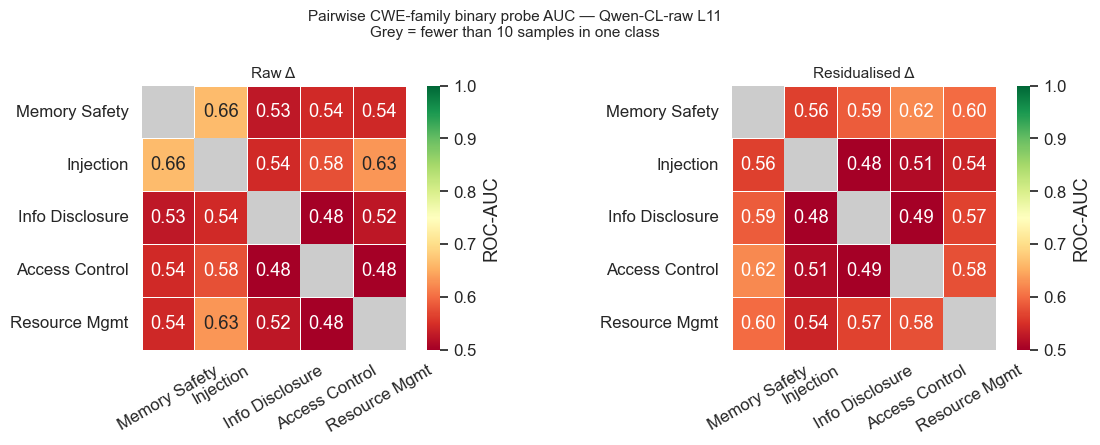

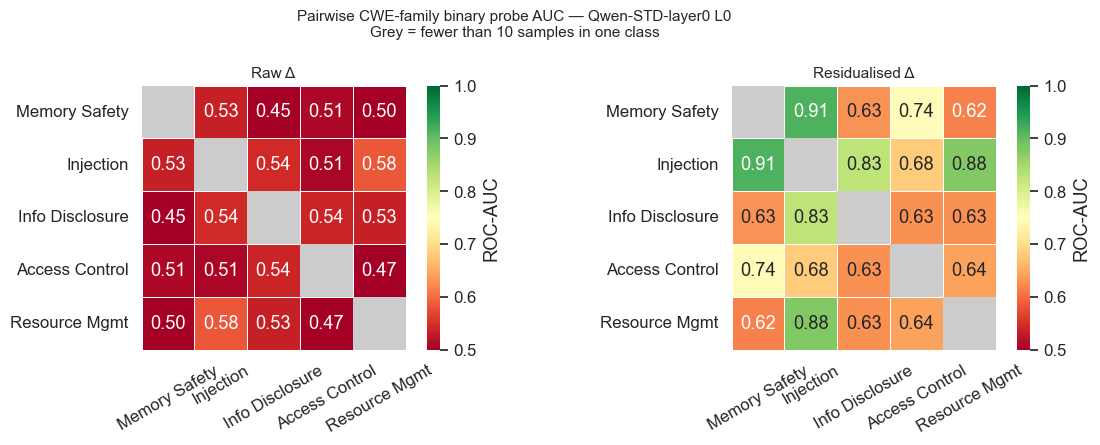

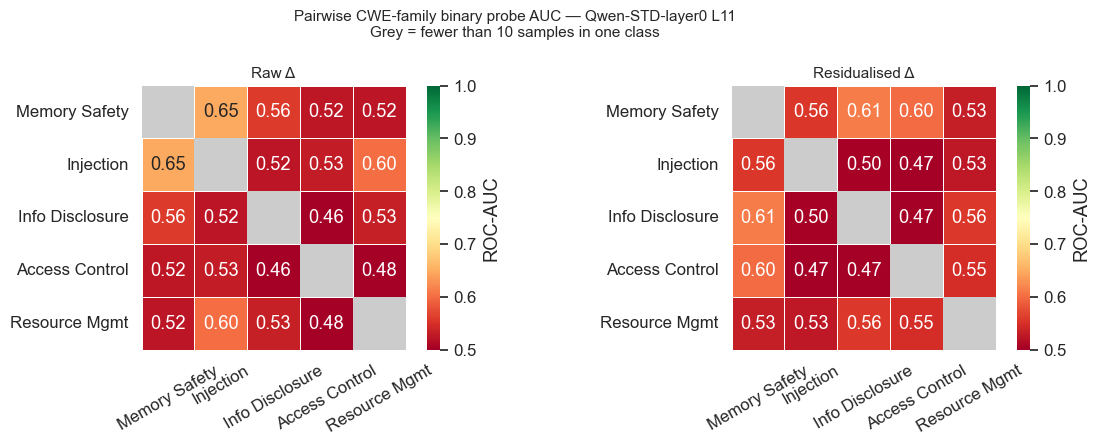


Δ pairwise AUC (resid − raw) per layer — negative = language confound:

Qwen-CL-raw L11:
                 Memory Safety  Injection  Info Disclosure  Access Control  Resource Mgmt
Memory Safety              NaN     -0.099            0.061           0.077          0.057
Injection               -0.099        NaN           -0.064          -0.066         -0.094
Info Disclosure          0.061     -0.064              NaN           0.017          0.043
Access Control           0.077     -0.066            0.017             NaN          0.093
Resource Mgmt            0.057     -0.094            0.043           0.093            NaN

Qwen-STD-layer0 L0:
                 Memory Safety  Injection  Info Disclosure  Access Control  Resource Mgmt
Memory Safety              NaN      0.381            0.175           0.234          0.116
Injection                0.381        NaN            0.282           0.174          0.296
Info Disclosure          0.175      0.282              NaN           0.090     

In [41]:
# ── Visualise: side-by-side raw vs residualised pairwise AUC matrices ─────────
for lbl in PAIRWISE_LAYERS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, (title, mat) in zip(axes, [
        ("Raw Δ",          pairwise_raw[lbl]),
        ("Residualised Δ", pairwise_resid[lbl]),
    ]):
        mask_nan = mat.isna()
        sns.heatmap(
            mat, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=ax, vmin=0.5, vmax=1.0, linewidths=0.5,
            mask=mask_nan,
            cbar_kws={"label": "ROC-AUC"},
            square=True,
        )
        # shade NaN cells grey
        for i in range(len(MAIN_FAMILIES)):
            for j in range(len(MAIN_FAMILIES)):
                if mask_nan.iloc[i, j]:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color="#cccccc", lw=0))
        ax.set_title(title, fontsize=11)
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

    fig.suptitle(
        f"Pairwise CWE-family binary probe AUC — {lbl}\n"
        "Grey = fewer than 10 samples in one class",
        fontsize=11,
    )
    plt.tight_layout()
    safe_lbl = lbl.replace(" ", "_")
    plt.savefig(f"pairwise_family_{safe_lbl}.pdf", bbox_inches="tight")
    plt.show()

# ── Δ (residualised − raw) to see which pairs are language-driven ──────────────
print("\nΔ pairwise AUC (resid − raw) per layer — negative = language confound:")
for lbl in PAIRWISE_LAYERS:
    diff = (pairwise_resid[lbl] - pairwise_raw[lbl]).round(3)
    print(f"\n{lbl}:")
    print(diff.to_string())